# <center><h2><b> <span style="color:blue">КУРСОВАЯ РАБОТА АССН</span></h2></b>    

## <span style="color:blue">Загрузка данных из 1 главы</span>   

In [1]:
run "data_G1.txt"

In [10]:
D = 0.495 #вероятность правльного обнаружения
h = 3000 #высота воздушного объекта

## <span style="color:blue">Моделирование процесса обнаружения в РЛС воздушного объекта</span>  

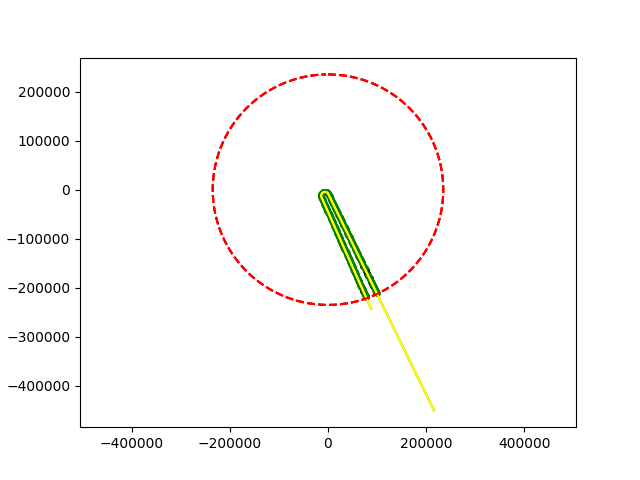

In [26]:
#определение i-x моментов обнаружения ВО (задача 1)
%matplotlib widget
import matplotlib.pyplot as plt
from numpy import random, exp, log, sqrt

# для графиков
x_det_p = []
y_det_p = []
x_no_det_p = []
y_no_det_p = []
#для расчетов
count_pount = len(x_coord)
p_i_arr = [] # массив вероятностей
a_i_arr = [] # массив фактов обнаружения/необнаружения
k = 0
d_zo = sqrt((point_round[0]*1000)**2 + h**2)

E_i_arr = random.uniform(low=0.0, high=1.0, size=count_pount)
        
for i in range(0, count_pount,10):
    r_i = sqrt(x_coord[i]**2 + y_coord[i]**2 + h**2)
    if r_i <= d_zo:
        p_i = exp(log(D)*(r_i/(point_round[0]*1000))**4)
        p_i_arr.append(p_i)
        if p_i >= E_i_arr[i]:
            a_i_arr.append(True)
            x_det_p.append(x_coord[i])
            y_det_p.append(y_coord[i])
        else:
            a_i_arr.append(False)
            x_no_det_p.append(x_coord[i])
            y_no_det_p.append(y_coord[i])
plt.axis('equal')
plt.plot(x_coord,y_coord,color='yellow')# траектория
plt.plot(x_rounds,y_rounds,color='red', linestyle="--")# злна обнаружения
plt.scatter(x_no_det_p, y_no_det_p, color="black", s=15)
plt.scatter(x_det_p, y_det_p, c="green", s=15)
plt.show()

In [ ]:
#определение i-x моментов обнаружения ВО (задача 2)

In [8]:
#ЯЧЕЙКА 6

import numpy as np
x_line_sum = []#МАССИВ ПО Х СО ВСЕХ ТРЕХ УЧАСТКОВ
x1_line = x_line[0::50] 
x2_line = x_manewr[0::50] 
x3_line = x_line2[0::50] 
for i in x1_line:
    x_line_sum.append(i)
for i in x2_line:
    x_line_sum.append(i)
for i in x3_line:
    x_line_sum.append(i)

y_line_sum = []#МАССИВ ПО У СО ВСЕХ ТРЕХ УЧАСТКОВ
y1_line = y_line[0::50] 
y2_line = y_manewr[0::50]
y3_line = y_line2[0::50] 
for i in y1_line:
    y_line_sum.append(i)
for i in y2_line:
    y_line_sum.append(i)
for i in y3_line:
    y_line_sum.append(i)

a=np.array(x_line_sum)# массив значений траекторий полета ВО по x
b=np.array(y_line_sum)# массив значений траекторий полета ВО по y
#НАКЛОННАЯ ДАЛЬНОСТЬ  ДО  ВО  
Dvo1= np.sqrt(a**2+b**2)# в данную переменную записать формулу расчета дальности до ВО   
xD=np.arange(1,len(Dvo1)+1)# разобраться с данной переменной, для чего она нужна
#ОШИБКА ИЗМЕРЕНИЯ ДАЛЬНОСТИ СКОо
sigma_r0=16875 # в данную переменную записать формулу расчета ошибки дальности до ВО   
#СКО ПО ДАЛЬНОСТИ
sigma_rj=np.sqrt(sigma_r0*3.1)
#ДАЛЬНОСТЬ ПЛЮС ОШИБКА
rj=Dvo1 + np.random.normal(0,sigma_rj,67)

plt.figure(figsize=(10,10))
    
plt.figure(figsize=(10,10))
  
c=np.arange(len(Dvo1))
d_obn = 0.495
line_detect = []
line_NOdetect= []

c1 = []
c2 = []
for p1 in range(0, len(a), 1):
    if np.random.random() >= d_obn:
        line_detect.append(sqrt(a[p1]**2+b[p1]**2))
        c1.append(c[p1])
    else:
        line_NOdetect.append(sqrt(a[p1]**2+b[p1]**2))
        c2.append(c[p1])

plt.plot(c,Dvo1,color='green')# ГРАФИК НАКЛОННОЙ ДАЛЬНОСТИ БЕЗ ОШИБКИ 
plt.plot(c,rj)#ГРАФИК НАКЛОННОЙ ДАЛЬНОСТИ С ОШИБКОЙ 
print(len(c1))
print(len(line_detect))
plt.scatter(c2, line_NOdetect, color="red", s=75,)
plt.scatter(c1, line_detect, color="green", s=75)
plt.grid()
plt.show()

NameError: name 'x_line' is not defined

Матожидание: 48.5664
Дисперсия: 40004.1150
СКО: 200.0103


C:\Users\roman\AppData\Local\Temp\ipykernel_20108\4124990221.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


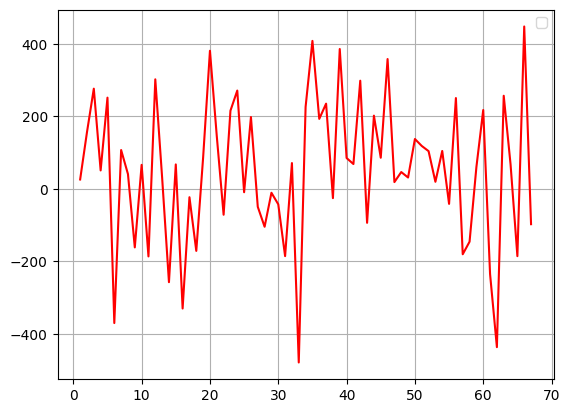

In [8]:
#ЯЧЕЙКА 7

delta_r = Dvo1 - rj

# Статистики
mean_delta_r = np.mean(delta_r)
var_delta_r = np.var(delta_r)
std_delta_r = np.std(delta_r)


print(f"Матожидание: {mean_delta_r:.4f}")
print(f"Дисперсия: {var_delta_r:.4f}")
print(f"СКО: {std_delta_r:.4f}")


plt.plot(xD,delta_r ,color='red')
plt.grid()
plt.legend()
plt.show()

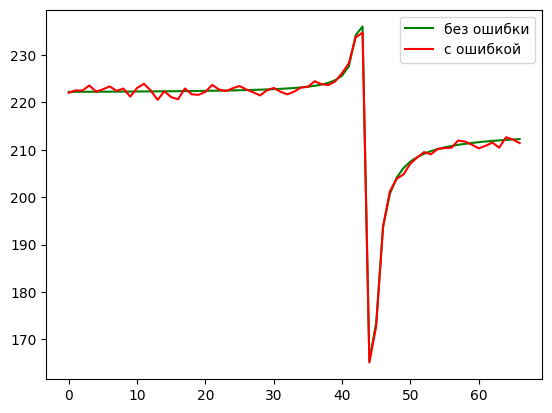

In [9]:
#ЯЧЕЙКА 8

import numpy as np
import math

def calculate_b(x,y):
    def arctg_deg(val):
        return math.degrees(math.atan(val))
# В СООТВЕТСТВИИ С МЕТОДИЧКОЙ МОДЕЛИРУЕМ ИЗМЕРЕНИЕ АЗИМУТА ДО ВО И ОШИБКУ
    if x>0 and y>0:
        return arctg_deg(x/y)
    elif x>0 and y<0:
        return 90+arctg_deg(abs(y)/x)
    elif x<0 and y<0:
        return 180+arctg_deg(x/y)
    elif x<0 and y>0:
        return 270+arctg_deg(y/abs(x))
    
    
x=np.array(x_line_sum)
y=np.array(y_line_sum)

b_values=[calculate_b(x_i,y_i) for x_i, y_i in zip(x,y)]# ЗНАЧЕНИЯ АЗИМУТА В ЗАВИСИМОСТИ ОТ КООРДИНАТ 

sigma_b0=(0.2*2)**2# в данную переменную записать формулу расчета ошибки азимута сигма 0
sigma_bj=np.sqrt(sigma_b0*(3.1))# в данную переменную записать формулу расчета ошибки азимута  

bj=b_values + np.random.normal(0,sigma_bj,67)# АЗИМУТ С ОШИБКОЙ

m=np.arange(len(b_values))

plt.plot(m,b_values, color='green', label='без ошибки')
plt.plot(m,bj, color='red', label='с ошибкой')
plt.legend()
plt.show()

Матожидание: 0.1336
Дисперсия: 0.5675
СКО: 0.7533


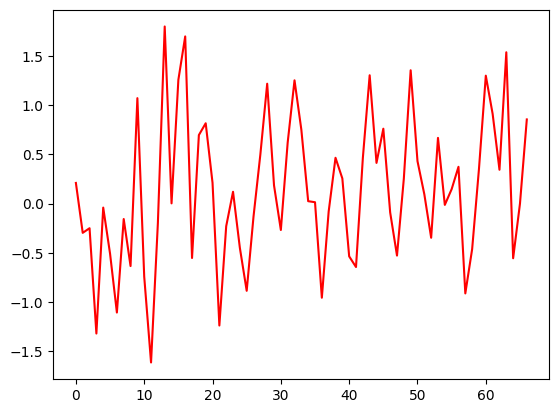

In [10]:
#ЯЧЕЙКА 9

delta_b = b_values - bj

# Статистики
mean_delta_b = np.mean(delta_b)
var_delta_b = np.var(delta_b)
std_delta_b = np.std(delta_b)

print(f"Матожидание: {mean_delta_b:.4f}")
print(f"Дисперсия: {var_delta_b:.4f}")
print(f"СКО: {std_delta_b:.4f}")

plt.plot(range(len(delta_b)),delta_b, color='red') 

[-0.01891892 -0.01937287 -0.01984915 -0.02034942 -0.02087557 -0.02142966
 -0.02201396 -0.02263102 -0.02328368 -0.02397509 -0.02470882 -0.02548887
 -0.02631977 -0.02720669 -0.02815546 -0.0291728  -0.0302664  -0.03144519
 -0.03271952 -0.03410147 -0.03560534 -0.03724795 -0.03904944 -0.04103406
 -0.04323122 -0.04567699 -0.04841613 -0.05150471 -0.05501419 -0.05903693
 -0.06369443 -0.06914961 -0.07562673 -0.08344285 -0.09306073 -0.10518445
 -0.12094035 -0.14224827 -0.17267014 -0.21964457 -0.30172801 -0.48177204
 -1.19458361 -1.44790761 -0.91326752 -0.59872005 -0.32765985 -0.22554648
 -0.17195663 -0.13894393 -0.11656556 -0.10039573 -0.08816538 -0.07859161
 -0.07089322 -0.0645685  -0.05927992 -0.05479205 -0.05093581 -0.04758672
 -0.04465084 -0.04205616 -0.03974646 -0.03767727 -0.03581286 -0.03412429
 -0.03258777]


C:\Users\roman\AppData\Local\Temp\ipykernel_20108\646839255.py:9: RuntimeWarning: invalid value encountered in arcsin
  ej_values=np.arcsin(engle_e)


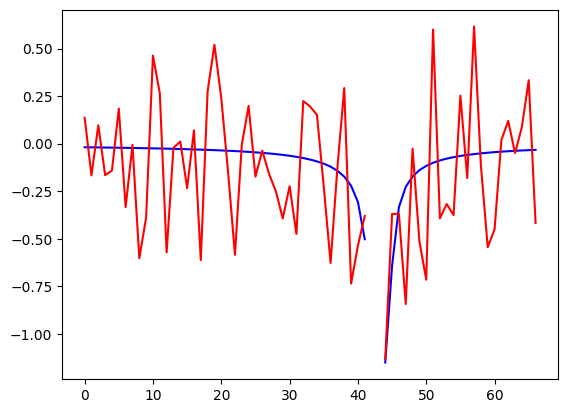

In [11]:
#ЯЧЕЙКА 10

import math
#РАСЧЕТ УГЛА МЕСТА С УЧЕТОМ ВЫСОТЫ ПОЛЕТА ВО
h_vo=7000
y_mass=np.array(y_line_sum)
engle_e=h_vo/y_mass
print(engle_e)
ej_values=np.arcsin(engle_e)


sigma_e0=(0.1*2)**2
sigma_ej=np.sqrt(sigma_e0*(3.1))#ОШИБКА ИЗМЕРЕНИЯ УГЛА МЕСТА

ej=ej_values + np.random.normal(0,sigma_ej,67)

k=np.arange(len(engle_e))

plt.plot(k,ej_values, color='blue', label='без ошибки')
plt.plot(k,ej, color='red', label='с ошибкой')





In [15]:
#ЯЧЕЙКА 11
%matplotlib widget
delta_e = ej_values - ej

# Статистики
mean_delta_e = np.mean(delta_e)
var_delta_e = np.var(delta_e)
std_delta_e = np.std(delta_e)

print(f"Матожидание: {mean_delta_e:.50f}")
print(f"Дисперсия: {var_delta_e:.4f}")
print(f"СКО: {std_delta_e:.4f}")

plt.plot(range(len(delta_e)),delta_e, color='red') 

Матожидание: nan
Дисперсия: nan
СКО: nan


# 